# 00. 全体像 — ベイズ推定は「信念の更新装置」

> この教材の読み方: 各章は **直感 → 数式 → Python 実装 → シミュレーション → 可視化 → 演習** の順で進みます。
> 本文は日本語、コードは英語、数式の中には日本語を入れません。乱数は seed 固定です。

## この章で分かること

- ベイズ推定とは何か、頻度主義と何が違うか
- この教材を貫く **6 ステップのフロー**
- 最小の実例(コイン投げ)で全体像を先取りする

```{admonition} 核心 — この教材のひとこと
:class: tip
**ベイズ推定とは「事前分布 × 尤度 → 事後分布」、すなわちデータで信念（確率分布）を更新する装置である。**
答えが点ではなく**分布**で返るので、不確実性ごと意思決定に持ち込める。
各章には、要点を一言で示す**「核心」**コールアウト、スライダーで動かせる図、現場での使われ方を示す**「実社会では」**コールアウトを置いた。
```

## 1. ベイズ推定とは何か

ベイズ推定は、**データを見るたびに信念(確率分布)を更新していく** 推論の枠組みです。
中心にあるのはベイズの定理ひとつだけ:

$$
p(\theta \mid x) = \frac{p(x \mid \theta)\, p(\theta)}{p(x)}
$$

記号の意味:

- $\theta$: 知りたい未知の量(コインの表率、CVR、回帰係数など)
- $x$: 観測されたデータ
- $p(\theta)$: **事前分布** — データを見る前の信念
- $p(x \mid \theta)$: **尤度** — その $\theta$ ならこのデータがどれくらい出やすいか
- $p(\theta \mid x)$: **事後分布** — データを見た後の、更新された信念
- $p(x)$: 正規化定数(エビデンス)

この教材では、どの章でも同じフローで考えます。

```text
仮説 → 事前分布 → データ → 尤度 → 事後分布 → 予測・意思決定
```

答えが「1 つの数値」ではなく **「分布」** で返ってくるのがベイズの特徴です。
分布で持っておけば、不確実性ごと意思決定に持ち込めます。

## 2. 頻度主義との違い

| | 頻度主義 | ベイズ |
|---|---|---|
| パラメータ $\theta$ | 固定された未知の定数 | 確率分布を持つ量 |
| 確率の意味 | 長期頻度 | 信念の度合い |
| 推定の出力 | 点推定 + 信頼区間 | 事後分布まるごと |
| 事前知識 | 持ち込まない | 事前分布として明示的に持ち込む |
| 「θ が区間に入る確率は 95%」 | 言えない(区間が確率変数) | 言える(信用区間) |

どちらが正しいという話ではなく、**事前知識を使いたい・不確実性を分布で扱いたい・
データが少ない**、という場面でベイズが強くなります。

In [1]:
# Shared setup. Every notebook in this book fixes the seed like this.
import matplotlib.pyplot as plt
import numpy as np

from bayes_textbook import visualization as viz
from bayes_textbook.conjugacy import BetaBinomial

rng = np.random.default_rng(42)
np.set_printoptions(precision=3, suppress=True)

## 3. 30秒プレビュー — コイン投げ

「このコイン、表が出る確率 $\theta$ はいくつ?」を 6 ステップで:

1. **仮説**: $\theta$ は 0 と 1 の間のどこか
2. **事前分布**: よく分からないので $\mathrm{Beta}(2, 2)$(0.5 付近がやや本命)
3. **データ**: 10 回投げて表 7 回
4. **尤度**: $\theta^7 (1-\theta)^3$
5. **事後分布**: $\mathrm{Beta}(2+7,\ 2+3) = \mathrm{Beta}(9, 5)$
6. **予測・意思決定**: 次も表の確率は事後平均 $9/14 \approx 0.64$

3 本の曲線(事前・尤度・事後)を重ねるこの図が、本書で最も大事な 1 枚です。

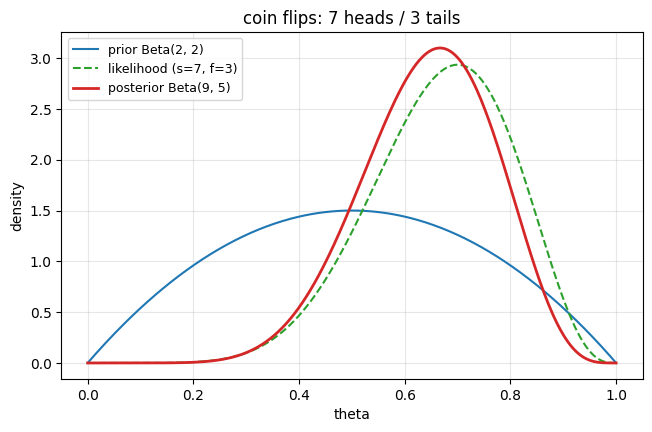

posterior mean = 0.643, 95% CI = [0.386, 0.861]


In [2]:
# The signature picture: prior x likelihood -> posterior, all on one axis.
prior = BetaBinomial(2, 2)
viz.plot_prior_likelihood_posterior(prior, successes=7, failures=3)
plt.title("coin flips: 7 heads / 3 tails")
plt.show()

post = prior.update(7, 3)
lo, hi = post.credible_interval(0.95)
print(f"posterior mean = {post.mean:.3f}, 95% CI = [{lo:.3f}, {hi:.3f}]")

事後分布は、事前分布と尤度の「妥協点」にできます。
データが増えるほど尤度が支配的になり、事前分布の影は薄れていきます(04 章で精密に)。

下のスライダーで投げた回数を動かしてみてください(表率 7 割のコインを想定。
この図は書き出した HTML 上でも動きます)。

In [3]:
# Slider preview: belief sharpening as flips accumulate (works in static HTML).
import plotly.io as pio

from bayes_textbook import visualization as viz

pio.renderers.default = "plotly_mimetype+notebook_connected"
theta_grid = np.linspace(0.001, 0.999, 300)
frames = []
for n in [0, 5, 20, 100, 500]:
    s = round(0.7 * n)
    p_n = prior.update(s, n - s)
    frames.append((f"{n}", [("posterior", p_n.dist.pdf(theta_grid), None),
                            ("prior", prior.dist.pdf(theta_grid), "dash")]))
fig = viz.plotly_curve_slider(theta_grid, frames, slider_name="flips",
                              title="watch the belief sharpen (true rate 0.7)")
fig.update_xaxes(title="theta")
fig.show()

## 4. この教材の構成

| 章 | 内容 | フローのどこか |
|---|---|---|
| 01 | ベイズの定理・条件付き確率・医療検査 | 定理そのもの |
| 02 | 頻出分布とシミュレーション | 事前分布・尤度の部品 |
| 03 | **ベータ二項モデル**(コイン・CVR・A/B テスト) | フロー一周目 |
| 04 | 共役事前分布・事後予測分布 | 事後 → 予測 |
| 05 | ベイズ線形回帰 | 連続値の回帰へ拡張 |
| 06 | **階層ベイズ**(部分プーリング・shrinkage) | 複数グループ |
| 07 | MCMC の直感(MH・Gibbs・HMC) | 事後を「計算する」技術 |
| 08 | PyMC 実践(+ ArviZ 診断) | 実務ツール |
| 09 | モデル検証と応用(PPC・WAIC・LOO) | 意思決定 |
| 10 | 演習解答 | — |

**03 と 06 が本書のコア**です。初読は 00→01→02→03 と進み、
03 で「ベイズの気持ちよさ」を体感してから先に進んでください。

## 5. 環境確認

下のセルが動けば準備完了です(PyMC は 08 章まで使いません。
読み込みに失敗してもこの章〜07 章はすべて動きます)。

In [4]:
# Environment check: core libraries (PyMC is optional until ch.08).
import importlib

for name in ["numpy", "scipy", "pandas", "matplotlib", "plotly", "ipywidgets", "bayes_textbook"]:
    mod = importlib.import_module(name)
    print(f"{name:>15}: {getattr(mod, '__version__', 'ok')}")
try:
    import pymc

    print(f"{'pymc':>15}: {pymc.__version__} (ch.08 ready)")
except Exception as e:  # noqa: BLE001 - any import failure just means ch.08 is locked
    print(f"{'pymc':>15}: not available ({type(e).__name__}) -> see README troubleshooting")

          numpy: 2.4.6
          scipy: 1.17.1
         pandas: 3.0.3
     matplotlib: 3.10.9
         plotly: 6.7.0
     ipywidgets: 8.1.8
 bayes_textbook: 0.1.0


           pymc: 6.0.1 (ch.08 ready)


## 6. まとめ

- ベイズ推定 = **事前分布 × 尤度 → 事後分布** という信念の更新。
- 出力は点ではなく **分布**。不確実性ごと意思決定に使える。
- 全章が「仮説 → 事前 → データ → 尤度 → 事後 → 予測」の同じフローで進む。
- まずは 03 章のベータ二項モデルまで一気に読むのがおすすめ。

次章: [01. ベイズの定理と確率の直感](01_bayes_theorem_and_probability.ipynb)